In [2]:
import polars as pl

cresta_new = pl.read_parquet(
    "../data/cresta_new/triad/staged/cresta_triad.conf.parquet"
)

<Axes: title={'center': 'CRESTA per-antigen AUC, (1 - mean_p_tcr_pae)'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

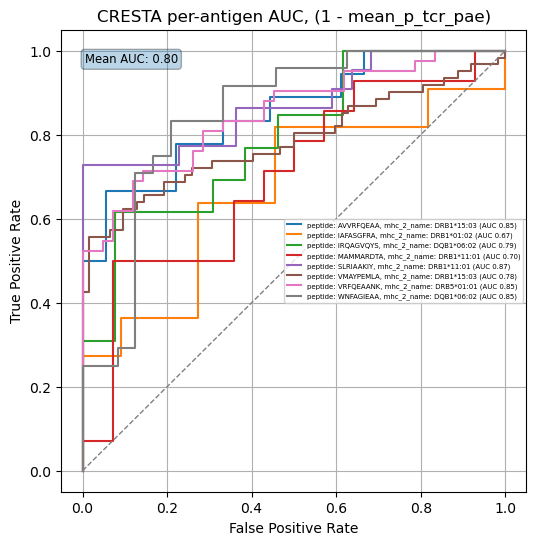

In [3]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen

auc_df = antigen_raw_score_auc(
    cresta_new.with_columns((1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
)

plot_auc_per_antigen(
    auc_df,
    id_cols=["peptide", "mhc_2_name"],
    title="CRESTA per-antigen AUC, (1 - mean_p_tcr_pae)",
)

<Axes: title={'center': 'CRESTA per-antigen AUC, original 5LR'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

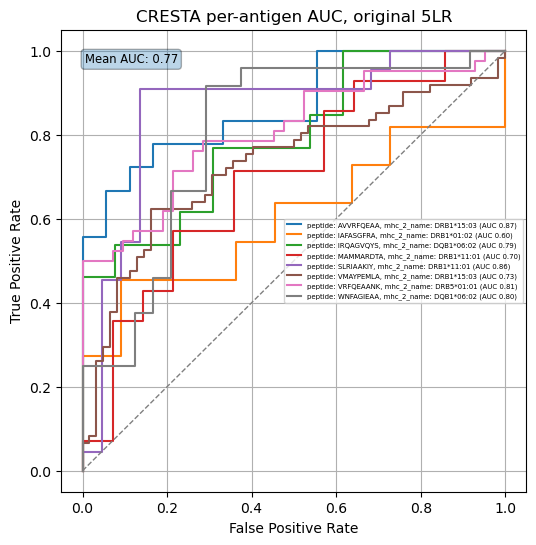

In [4]:
from tcrtrifold.eval_utils import antigen_cross_validation_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen
import sklearn

lr_feat = [
    "peptide_mean_pLDDT",
    "tcr_mhc_contacts",
    "peptide_tcr_contacts",
    "tcr_cdrs_mean_pLDDT",
    "mhc_helices_mean_pLDDT",
]

auc_df = antigen_cross_validation_auc(
    cresta_new, lr_feat, sklearn.linear_model.LogisticRegression, {}
)

plot_auc_per_antigen(
    auc_df,
    id_cols=["peptide", "mhc_2_name"],
    title="CRESTA per-antigen AUC, original 5LR",
)